# Лабораторная работа 4

## Реализация LSTM из статьи

В работе воспроизводится подход из статьи о прогнозировании временных рядов солнечной активности. Модель по 135 предыдущим дням прогнозирует значения `R` и `F10.7` на 27 дней вперёд.


### Цель работы

Реализовать encoder-decoder LSTM-сеть из статьи, подготовить данные, обучить модель и сравнить прогноз с наблюдениями.


### Импорт библиотек

Подключаем инструменты для таблиц, графиков, массивов и нейронной сети.


In [1]:
import pandas as pd
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, BatchNormalization, RepeatVector, Reshape, TimeDistributed, Dense
from tensorflow.keras.utils import plot_model

2025-05-27 03:44:33.030594: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-27 03:44:33.057622: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-27 03:44:33.058437: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-27 03:44:33.601440: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


### Проверка GPU

Если TensorFlow видит GPU, обучение пойдёт на видеокарте. Иначе будет использоваться CPU.


In [ ]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    DEVICE_NAME = '/GPU:0'
    print('TensorFlow будет обучать модель на GPU:', gpus)
else:
    DEVICE_NAME = '/CPU:0'
    print('GPU не найден. Обучение пойдет на CPU.')
    print('Чтобы обучение шло на GPU, TensorFlow должен видеть видеокарту в списке физических устройств.')

In [ ]:
print('Версия TensorFlow:', tf.__version__)
print('Физические GPU:', tf.config.list_physical_devices('GPU'))
print('Логические GPU:', tf.config.list_logical_devices('GPU'))

### Загрузка данных

Исходный файл `data.csv` содержит дневные значения `R` и `F10.7`. Столбец `HR` в работе не используется.


In [2]:
data = pd.read_csv('data.csv', delimiter=';')
data = data.drop(columns='HR')

### Интерполяция пропущенных значений

Значение `999.9` в ряду `F10.7` считается пропуском и восстанавливается линейной интерполяцией.


In [3]:
data['F10.7'] = data['F10.7'].replace(999.9, float('nan'))
data['F10.7'] = data['F10.7'].interpolate()

In [4]:
data

,YEAR,DDY,R,F10.7
0,1963,332,31,79.0
1,1963,333,39,79.0
2,1963,334,40,79.0
3,1963,335,40,79.0
4,1963,336,44,80.0
...,...,...,...,...
21639,2023,56,127,273.7
21640,2023,57,119,155.9
21641,2023,58,126,158.1
21642,2023,59,91,157.9


### Формирование временной шкалы

По полям `YEAR` и `DDY` создаётся календарная дата, которая дальше используется как индекс.


In [4]:
data['Date'] = pd.to_datetime(data['YEAR'].astype(str) + '-' + data['DDY'].astype(str).str.zfill(3), format='%Y-%j')
data.set_index('Date', inplace=True)

### Исходные временные ряды

На графиках показаны исходные ряды `R` и `F10.7`.


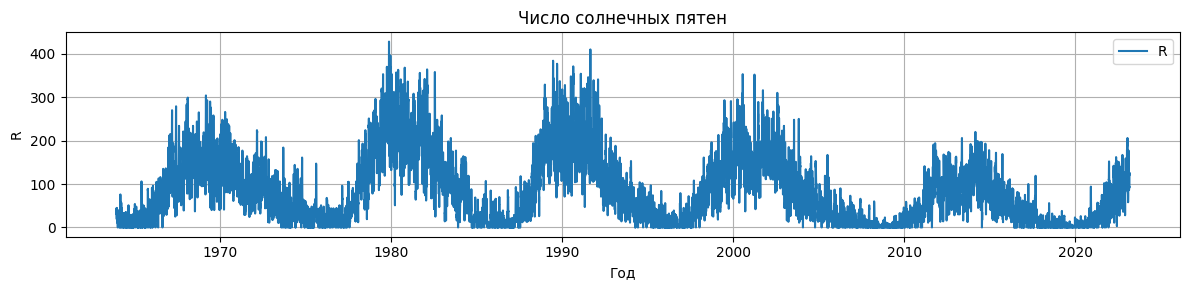

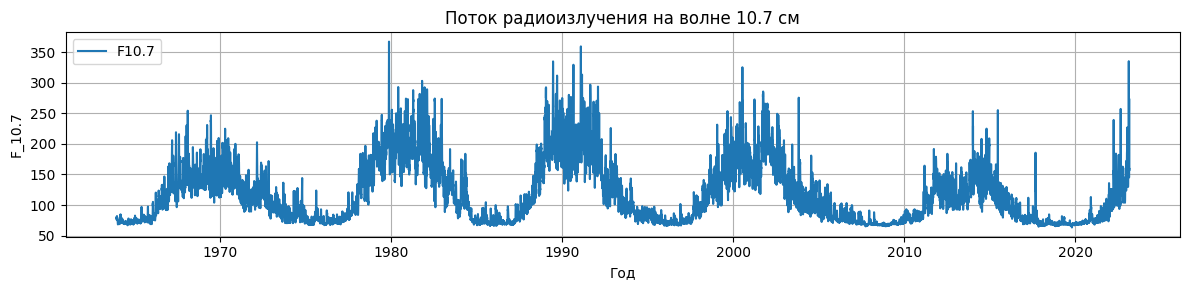

In [5]:
plt.figure(figsize=(12, 3))
plt.plot(data.index, data['R'], label='R')
plt.title('Число солнечных пятен')
plt.xlabel('Год')
plt.ylabel('R')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(data.index, data['F10.7'], label='F10.7')
plt.title('Поток радиоизлучения на волне 10.7 см')
plt.xlabel('Год')
plt.ylabel('F_10.7')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Нормировка данных

Оба ряда переводятся в диапазон от 0 до 1.


In [7]:
R_min, R_max = data['R'].min(), data['R'].max()
F10_7_min, F10_7_max = data['F10.7'].min(), data['F10.7'].max()

data['R_norm'] = (data['R'] - R_min) / (R_max - R_min)
data['F10.7_norm'] = (data['F10.7'] - F10_7_min) / (F10_7_max - F10_7_min)

### Нормированные ряды

После нормировки признаки сохраняют форму исходных рядов, но имеют единый масштаб.


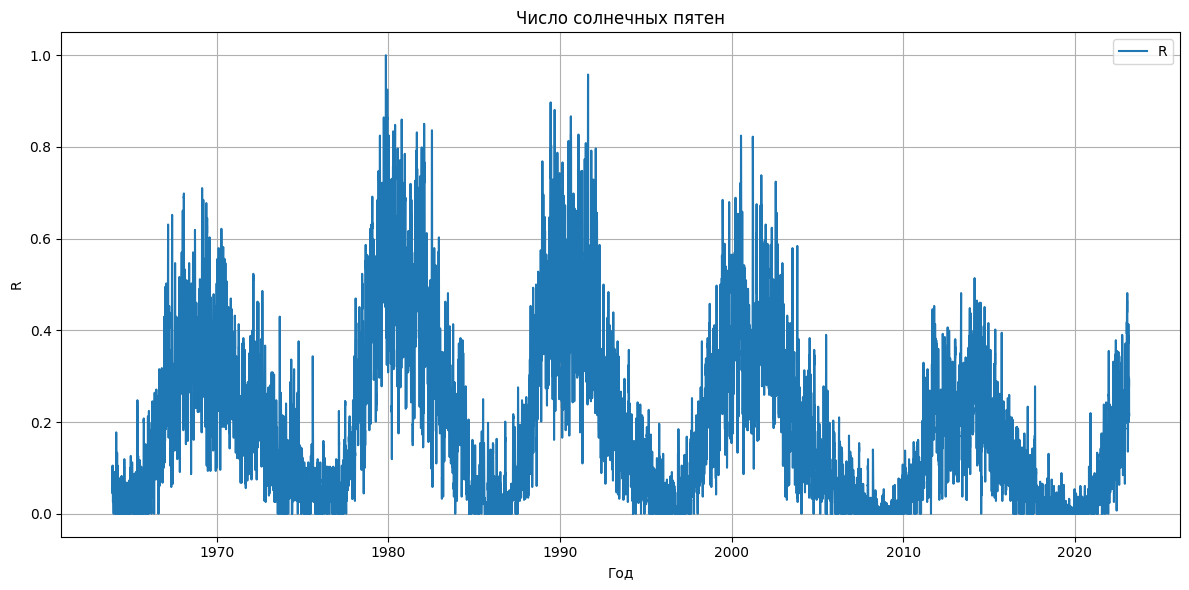

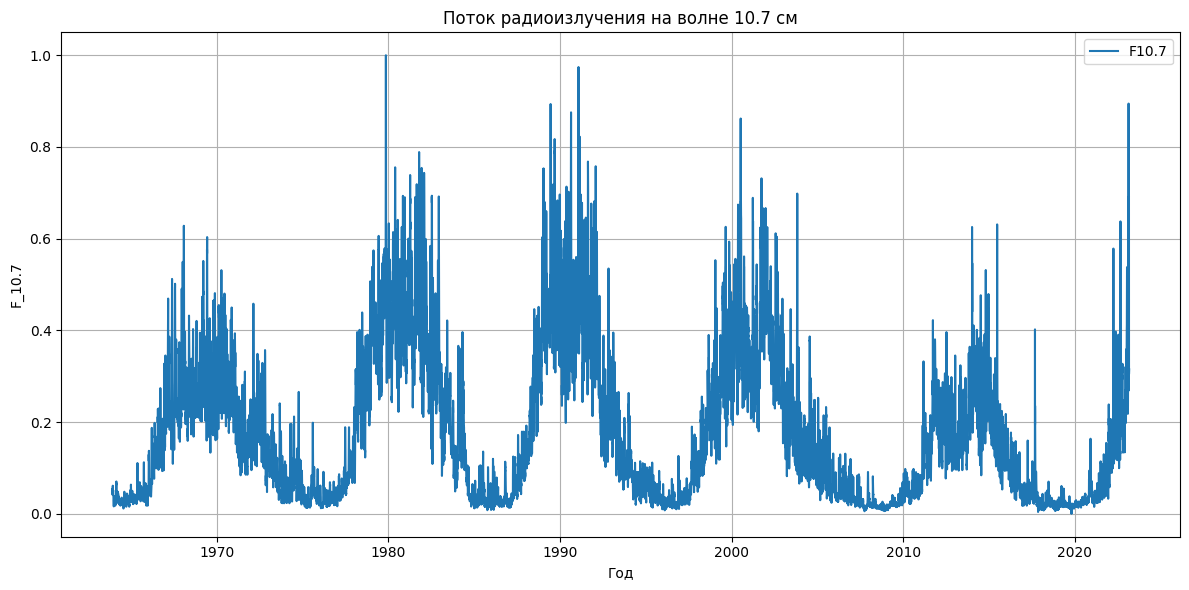

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['R_norm'], label='R')
plt.title('Число солнечных пятен')
plt.xlabel('Год')
plt.ylabel('R')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(data.index, data['F10.7_norm'], label='F10.7')
plt.title('Поток радиоизлучения на волне 10.7 см')
plt.xlabel('Год')
plt.ylabel('F_10.7')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Подготовка обучающих последовательностей

На вход подаётся 135 дней, на выходе формируется прогноз на 27 дней. В каждом дне два признака: `R_norm` и `F10.7_norm`.


In [9]:
input_length = 135
output_length = 27
n_features = 2
data_norm = data[['R_norm', 'F10.7_norm']].values

X, y = [], []
for i in range(len(data_norm) - input_length - output_length + 1):
    X.append(data_norm[i:i + input_length])
    y.append(data_norm[i + input_length:i + input_length + output_length])
X, y = np.array(X), np.array(y)

print(f'Размер входного массива X: {X.shape}')
print(f'Размер целевого массива y: {y.shape}')

Размер входного массива X: (21483, 135, 2)
Размер целевого массива y: (21483, 27, 2)


### Разделение на обучение и проверку

Ряд не перемешивается: первые 80 % идут в обучение, последние 20 % - в проверку.


In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

### Архитектура LSTM из статьи

Используется encoder-decoder схема из двух LSTM-сетей по 50 нейронов. Первая LSTM кодирует ряд, вторая LSTM строит прогноз на 27 шагов.


![Схема LSTM-модели из статьи](images/sxema.png)


In [ ]:
units = 50

inputs = Input(shape=(input_length, n_features), name='input_1')

# Первая LSTM-сеть кодирует входную последовательность.
# return_state=True возвращает скрытое состояние h и внутреннее состояние c.
encoder_output, state_h, state_c = LSTM(
    units,
    return_sequences=False,
    return_state=True,
    name='lstm_1'
)(inputs)

# В схеме из статьи состояния первой LSTM нормализуются и подаются во вторую LSTM.
state_h = BatchNormalization(name='batch_normalization')(state_h)
state_c = BatchNormalization(name='batch_normalization_1')(state_c)

# Повторяем скрытое состояние на 27 будущих шагов.
repeat_vector = RepeatVector(output_length, name='repeat_vector')(state_h)

# Вторая LSTM-сеть строит прогноз, начиная с состояний первой LSTM.
decoder_output = LSTM(
    units,
    return_sequences=True,
    name='lstm_2'
)(repeat_vector, initial_state=[state_h, state_c])

# На каждом из 27 шагов выдаем два значения: R и F10.7.
outputs = TimeDistributed(Dense(n_features), name='time_distributed')(decoder_output)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mae')

model.summary()

### Схема модели

Если доступен Graphviz, схема модели сохраняется в `model_plot.png`.


In [ ]:
import shutil

if shutil.which('dot') is None:
    print('Graphviz dot.exe не найден в PATH. Схема модели не будет сохранена.')
    print('Установите системный Graphviz и перезапустите VS Code/Jupyter.')
else:
    plot_model(
        model,
        to_file='model_plot.png',
        show_shapes=True,
        show_layer_names=True,
        rankdir='TB',
        expand_nested=False,
        dpi=96
    )

### Обучение и сохранение модели

После первого обучения модель и история ошибки сохраняются. При повторном запуске модель загружается из файла.


In [ ]:
MODEL_PATH = Path('solar_activity_lstm_encoder_decoder.keras')
HISTORY_PATH = Path('solar_activity_lstm_encoder_decoder_history.csv')
DEVICE_NAME = globals().get('DEVICE_NAME', '/GPU:0' if tf.config.list_physical_devices('GPU') else '/CPU:0')

print(f'Используемое устройство для модели: {DEVICE_NAME}')

with tf.device(DEVICE_NAME):
    if MODEL_PATH.exists():
        model = tf.keras.models.load_model(MODEL_PATH)
        history_df = pd.read_csv(HISTORY_PATH) if HISTORY_PATH.exists() else None
        print(f'Загружена сохраненная модель: {MODEL_PATH}')
    else:
        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=32,
            validation_data=(X_val, y_val),
            verbose=1
        )
        model.save(MODEL_PATH)
        history_df = pd.DataFrame(history.history)
        history_df.to_csv(HISTORY_PATH, index=False)
        print(f'Модель сохранена в файл: {MODEL_PATH}')
        print(f'История обучения сохранена в файл: {HISTORY_PATH}')

### График ошибки

Ниже строится график MAE на обучающей и проверочной выборках.


In [ ]:
if history_df is not None and {'loss', 'val_loss'}.issubset(history_df.columns):
    train_mae = history_df['loss']
    val_mae = history_df['val_loss']

    plt.figure(figsize=(10, 6))
    plt.plot(train_mae, label='MAE на обучении', color='blue')
    plt.plot(val_mae, label='MAE на проверке', color='orange')
    plt.xlabel('Эпохи')
    plt.ylabel('Средняя абсолютная ошибка')
    plt.title('Зависимость MAE от числа эпох')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('История обучения не найдена. График MAE появится после первого обучения модели.')

### Сравнение прогноза и наблюдений

Строятся графики прогнозов на 1, 4 и 20 дней, а также отдельный прогноз на 27 дней.


In [ ]:
import matplotlib.dates as mdates

y_pred = model.predict(X_val)

n_train = len(X_train)
test_start_index = n_train + input_length
test_target_dates = data.index[test_start_index:test_start_index + len(X_val)]

def denormalize(values, min_value, max_value):
    return values * (max_value - min_value) + min_value

def plot_test_horizons(feature_index, column_name, min_value, max_value, ylabel, title):
    horizons = [1, 4, 20]
    colors = {1: 'blue', 4: 'green', 20: 'olive'}
    labels = {1: 'прогноз на 1 день', 4: 'прогноз на 4 дня', 20: 'прогноз на 20 дней'}

    plot_from = pd.Timestamp('2021-01-01')
    plot_to = data.index[-1]
    observed = data.loc[plot_from:plot_to, column_name]

    plt.figure(figsize=(12, 5))
    for horizon in horizons:
        target_indices = n_train + input_length + (horizon - 1) + np.arange(len(X_val))
        target_dates = data.index[target_indices]
        forecast = denormalize(y_pred[:, horizon - 1, feature_index], min_value, max_value)
        mask = (target_dates >= plot_from) & (target_dates <= plot_to)
        plt.plot(target_dates[mask], forecast[mask], color=colors[horizon], linewidth=1, label=labels[horizon])

    plt.plot(observed.index, observed.values, color='red', linewidth=1, label='наблюдения')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.4)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m\n%Y'))
    plt.tight_layout()
    plt.show()

plot_test_horizons(
    feature_index=0,
    column_name='R',
    min_value=R_min,
    max_value=R_max,
    ylabel='Число солнечных пятен',
    title='Результаты работы модели на тестовом ряду R'
)

plot_test_horizons(
    feature_index=1,
    column_name='F10.7',
    min_value=F10_7_min,
    max_value=F10_7_max,
    ylabel='Поток радиоизлучения F10.7',
    title='Результаты работы модели на тестовом ряду F10.7'
)

desired_start_date = pd.Timestamp('2022-10-25')
sample_index = int(np.argmin(np.abs(test_target_dates - desired_start_date)))
forecast_start_index = n_train + sample_index + input_length
forecast_dates = data.index[forecast_start_index:forecast_start_index + output_length]

real_R = denormalize(y_val[sample_index, :, 0], R_min, R_max)
pred_R = denormalize(y_pred[sample_index, :, 0], R_min, R_max)
real_F10_7 = denormalize(y_val[sample_index, :, 1], F10_7_min, F10_7_max)
pred_F10_7 = denormalize(y_pred[sample_index, :, 1], F10_7_min, F10_7_max)

print(f'Прогноз на 27 дней: с {forecast_dates[0].date()} по {forecast_dates[-1].date()}')
print(f'MAE для R: {np.mean(np.abs(real_R - pred_R)):.3f}')
print(f'MAE для F10.7: {np.mean(np.abs(real_F10_7 - pred_F10_7)):.3f}')

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(forecast_dates, pred_R, color='blue', linewidth=1.5, label='прогноз')
axes[0].plot(forecast_dates, real_R, color='red', linewidth=1.2, label='наблюдения')
axes[0].set_ylabel('Число солнечных пятен')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.35)
axes[0].text(0.5, -0.22, 'а', transform=axes[0].transAxes, ha='center', va='center', fontstyle='italic')

axes[1].plot(forecast_dates, pred_F10_7, color='blue', linewidth=1.5, label='прогноз')
axes[1].plot(forecast_dates, real_F10_7, color='red', linewidth=1.2, label='наблюдения')
axes[1].set_ylabel('Поток радиоизлучения F10.7')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.35)
axes[1].text(0.5, -0.30, 'б', transform=axes[1].transAxes, ha='center', va='center', fontstyle='italic')

axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%d.%m'))
plt.setp(axes[1].get_xticklabels(), rotation=90)
plt.tight_layout()
plt.show()

### Вывод

В ноутбуке реализована LSTM-модель по схеме из статьи. Графики позволяют сравнить прогнозные и реальные значения солнечной активности.
